# Stage 1: Define Prediction Grid

Creates cluster-sized prediction points across 10 target provinces + NCR.
Uses **PSGC shapefiles** from [altcoder/philippines-psgc-shapefiles](https://github.com/altcoder/philippines-psgc-shapefiles) which have the updated Maguindanao del Norte / del Sur split.

**Target areas (5 lowest poverty incidence):**
- Ilocos Norte (0.3%), Pampanga (1.0%), Benguet (2.5%), Kalinga (2.6%), Aklan (3.1%)

**Target areas (5 highest poverty incidence):**
- Zamboanga del Norte (37.7%), Basilan (33.7%), Tawi-Tawi (32.3%), Maguindanao del Sur (32.1%), Davao Oriental (29.1%)

**Plus:** NCR

**Output:** `prediction_points.csv`

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import os
import warnings
from shapely.geometry import Point
warnings.filterwarnings('ignore')
print(f"GeoPandas: {gpd.__version__}")

GeoPandas: 1.1.2


In [2]:
# ============================================================
# 1. CONFIGURATION
# ============================================================

# PSGC shapefiles from: https://github.com/altcoder/philippines-psgc-shapefiles
# Unzip PH_Adm3_MuniCities.shp.zip
PSGC_DIR = '/Users/ruben/Desktop/Thesis/2025Data/'
MUNI_SHP = f'{PSGC_DIR}/PH_Adm3_MuniCities.shp'
#PROV_SHP = f'{PSGC_DIR}/PH_Adm2_ProvDists.shp'

# DHS cluster shapefile
DHS_SHP = '/Users/ruben/Desktop/Thesis/TrainingData/PH_DHS_GPS/PHGE81FL/PHGE81FL.shp'

# Output
OUTPUT_DIR = '/Users/ruben/Desktop/Thesis/2025Data/bulacan/input'
os.makedirs(OUTPUT_DIR, exist_ok=True)

GRID_RURAL_M = 5000
GRID_URBAN_M = 2000
PH_CRS = 'EPSG:32651'

TARGET_PROVINCES = [
    'Ilocos Norte', 'Pampanga', 'Benguet', 'Kalinga', 'Aklan',
    'Zamboanga del Norte', 'Basilan', 'Tawi-Tawi',
    'Maguindanao del Sur', 'Davao Oriental', 'Bataan', 'Oriental Mindoro',
    'Occidental Mindoro', 'Zambales', 'Bulacan'
]

NCR_REGION_NAME = 'NCR'
SEED = 42
np.random.seed(SEED)

print(f"Target: {len(TARGET_PROVINCES)} provinces + NCR")

Target: 15 provinces + NCR


In [3]:
# ============================================================
# 2. LOAD MUNICIPALITIES AND FILTER VIA P-CODE DICTIONARY
# ============================================================

# The dictionary derived directly from the official UN OCHA CSVs
# Maps Province Name -> PSGC Prefix
PROVINCE_PREFIXES = {
    'Ilocos Norte': '1028',
    'Pampanga': '3054',
    'Benguet': '14011',
    'Kalinga': '14032',
    'Aklan': '6004',
    'Zamboanga del Norte': '9072',
    'Basilan': '19007',
    'Tawi-Tawi': '19070',
    'Maguindanao del Sur': '19088', # Updated Maguindanao split code!
    'Davao Oriental': '11025',
    'NCR': '13',  # All NCR municipalities start with 13
    'Bataan'             : '3008',   # Region III
    'Zambales'           : '3071',   # Region III
    'Occidental Mindoro' : '17051',   # Region IV-B (MIMAROPA)
    'Oriental Mindoro'   : '17052',
    'Bulacan'            : '3014',   # Region III (same as Bataan, but we will differentiate later by municipality name)   
}

OLONGAPO_PREFIX = '3314'   # confirm this from Step 1 output
ANGELES_PREFIX = '3301'   # Note: Angeles City is a HUC but shares the same PSGC prefix as the rest of Pampanga, so it will be labeled as Pampanga in the Province column but can be flagged separately if needed.

print("Loading PSGC municipality boundaries...")
gdf_muni = gpd.read_file(MUNI_SHP)

# Force columns to lowercase to prevent capitalization errors
gdf_muni.columns = gdf_muni.columns.str.lower()

# Clean PSGC codes (remove any accidental .0 and ensure they are strings)
gdf_muni['psgc_code'] = gdf_muni['psgc_code'].astype(str).str.replace('.0', '', regex=False)

# Create empty columns for our standard naming convention
gdf_muni['Province'] = None
gdf_muni['Municipality'] = gdf_muni['name']

print("Applying Province labels via PSGC prefixes...")

# Map the provinces by checking if the municipality code starts with the dictionary prefix
for prov, prefix in PROVINCE_PREFIXES.items():
    mask = gdf_muni['psgc_code'].str.startswith(prefix)
    gdf_muni.loc[mask, 'Province'] = prov
    
# Olongapo City: HUC with its own prefix, grouped under Zambales
olongapo_mask = gdf_muni['psgc_code'].str.startswith(OLONGAPO_PREFIX)
gdf_muni.loc[olongapo_mask, 'Province'] = 'Zambales'

# Angele City: HUC with its own prefix, grouped under Pampanga
angeles_mask = gdf_muni['psgc_code'].str.startswith(ANGELES_PREFIX)
gdf_muni.loc[angeles_mask, 'Province'] = 'Pampanga'

# After assigning the Province column
URBAN_HCUS = {'City of Olongapo', 'City of Angeles',
              }   # add other HUCs here if needed later

gdf_muni['is_urban_huc'] = gdf_muni['name'].isin(URBAN_HCUS)

# Filter down to ONLY our target areas (anything that successfully got a Province name)
gdf_target = gdf_muni[gdf_muni['Province'].notna()].copy()

# Flag NCR for the grid logic later
gdf_target['is_ncr'] = gdf_target['Province'] == 'NCR'

print(f"\nFiltered to {len(gdf_target)} municipalities across:")
for prov, count in gdf_target['Province'].value_counts().items():
    print(f"  {prov}: {count} municipalities")

gdf_target = gdf_target.to_crs(PH_CRS)
print(f"\nReprojected to {PH_CRS}")

Loading PSGC municipality boundaries...
Applying Province labels via PSGC prefixes...

Filtered to 261 municipalities across:
  Zamboanga del Norte: 27 municipalities
  Bulacan: 24 municipalities
  Maguindanao del Sur: 24 municipalities
  Ilocos Norte: 23 municipalities
  Pampanga: 22 municipalities
  Aklan: 17 municipalities
  NCR: 17 municipalities
  Oriental Mindoro: 15 municipalities
  Zambales: 14 municipalities
  Benguet: 13 municipalities
  Bataan: 12 municipalities
  Basilan: 12 municipalities
  Davao Oriental: 11 municipalities
  Occidental Mindoro: 11 municipalities
  Tawi-Tawi: 11 municipalities
  Kalinga: 8 municipalities

Reprojected to EPSG:32651


In [4]:
# ============================================================
# 3. CREATE GRID POINTS
# ============================================================
# Map the old variables to our clean, dictionary-derived columns
COL_PROVINCE = 'Province'
COL_MUNI     = 'Municipality'
COL_PCODE    = 'psgc_code'
COL_REGION   = 'adm1_pcode' # The raw region code from the shapefile
def generate_grid_within_polygon(polygon, spacing_m):
    minx, miny, maxx, maxy = polygon.bounds
    xs = np.arange(minx, maxx, spacing_m)
    ys = np.arange(miny, maxy, spacing_m)
    points = []
    for x in xs:
        for y in ys:
            pt = Point(x, y)
            if polygon.contains(pt):
                points.append(pt)
    return points

print("Generating prediction grid...")
all_points = []
point_id = 1

for idx, row in gdf_target.iterrows():
    municipality = row[COL_MUNI]
    province = row[COL_PROVINCE]
    region = row[COL_REGION]
    is_ncr = row['is_ncr']
    pcode = row.get(COL_PCODE, None)

    is_urban = row['is_ncr'] or row.get('is_urban_huc', False)
    spacing  = GRID_URBAN_M if is_urban else GRID_RURAL_M   
    polygon = row.geometry
    if polygon is None or polygon.is_empty:
        continue

    if polygon.geom_type == 'MultiPolygon':
        sub_polys = list(polygon.geoms)
    else:
        sub_polys = [polygon]

    muni_points = []
    for poly in sub_polys:
        pts = generate_grid_within_polygon(poly, spacing)
        muni_points.extend(pts)

    if len(muni_points) == 0:
        centroid = polygon.centroid
        if polygon.contains(centroid):
            muni_points = [centroid]
        else:
            muni_points = [polygon.representative_point()]

    for pt in muni_points:
        all_points.append({
            'PointID': point_id,
            'Municipality': municipality,
            'Province': province,
            'Region': region,
            'PSGC': pcode,
            'is_ncr': is_ncr,
            'is_urban_huc': row.get('is_urban_huc', False),
            'geometry': pt
        })
        point_id += 1

gdf_points = gpd.GeoDataFrame(all_points, crs=PH_CRS)
print(f"\nTotal grid points: {len(gdf_points)}")
for prov, count in gdf_points['Province'].value_counts().items():
    print(f"  {prov}: {count}")

Generating prediction grid...

Total grid points: 1881
  Occidental Mindoro: 236
  Zamboanga del Norte: 233
  Davao Oriental: 187
  Zambales: 165
  Oriental Mindoro: 148
  NCR: 139
  Ilocos Norte: 112
  Kalinga: 107
  Pampanga: 103
  Benguet: 101
  Bulacan: 92
  Maguindanao del Sur: 82
  Aklan: 55
  Bataan: 50
  Tawi-Tawi: 36
  Basilan: 35


In [5]:
# ============================================================
# 3B. CHECK DENSITY
# ============================================================

muni_counts = gdf_points.groupby(
    ['Province', 'Municipality']
).size().reset_index(name='n_points')
print("Points per municipality (top 20):")
print(muni_counts.sort_values('n_points', ascending=False).head(20).to_string(index=False))
print(f"\nMunicipalities with 1 point: {(muni_counts['n_points'] == 1).sum()}")
print(f"Total: {len(gdf_points)}")

Points per municipality (top 20):
           Province           Municipality  n_points
 Occidental Mindoro               Sablayan        81
                NCR            Quezon City        41
            Bulacan Doña Remedios Trinidad        39
           Zambales       City of Olongapo        35
     Davao Oriental                Baganga        32
 Occidental Mindoro             Santa Cruz        29
            Kalinga          City of Tabuk        28
           Pampanga        City of Angeles        28
     Davao Oriental           City of Mati        27
 Occidental Mindoro                 Paluan        25
 Occidental Mindoro               San Jose        24
   Oriental Mindoro                 Naujan        23
            Kalinga               Balbalan        23
           Zambales                Botolan        23
       Ilocos Norte              Nueva Era        23
 Occidental Mindoro           Abra De Ilog        22
Zamboanga del Norte                 Sibuco        22
     Davao O

In [6]:
# ============================================================
# 3C. CLIP GRID TO TRUE LANDMASS
# ============================================================

print("Loading true landmass boundaries...")
# UPDATE THIS PATH to wherever you saved the National/ADM0 shapefile
ADM0_SHP = '/Users/ruben/Desktop/Thesis/2025Data/gadm41_PHL_shp/gadm41_PHL_0.shp' 

ph_landmass = gpd.read_file(ADM0_SHP).to_crs(PH_CRS)

print("Clipping ocean points...")
print(f"Points before clipping: {len(gdf_points)}")

# Keep ONLY the prediction points that physically intersect the land polygon
gdf_points = gpd.sjoin(gdf_points, ph_landmass[['geometry']], how='inner', predicate='intersects')

# Clean up the extra index column created by the spatial join
gdf_points = gdf_points.drop(columns=['index_right'], errors='ignore')

print(f"Points after clipping: {len(gdf_points)}")

# Quick density check update
muni_counts_clipped = gdf_points.groupby(['Province', 'Municipality']).size().reset_index(name='n_points')
print("\nNew points per municipality (top 5):")
print(muni_counts_clipped.sort_values('n_points', ascending=False).head(5).to_string(index=False))

Loading true landmass boundaries...
Clipping ocean points...
Points before clipping: 1881
Points after clipping: 1876

New points per municipality (top 5):
          Province           Municipality  n_points
Occidental Mindoro               Sablayan        81
               NCR            Quezon City        41
           Bulacan Doña Remedios Trinidad        39
          Zambales       City of Olongapo        35
    Davao Oriental                Baganga        32


In [7]:
# ============================================================
# 4. ADD DHS CLUSTERS
# ============================================================

print("Loading DHS cluster locations...")
gdf_dhs = gpd.read_file(DHS_SHP).to_crs(PH_CRS)
print(f"Total DHS clusters: {len(gdf_dhs)}")

dhs_in_target = gpd.sjoin(
    gdf_dhs,
    gdf_target[[COL_PROVINCE, COL_MUNI, COL_REGION, 'is_ncr', 'geometry']],
    how='inner', predicate='within'
)
print(f"DHS clusters inside target areas: {len(dhs_in_target)}")

dhs_points = []
for idx, row in dhs_in_target.iterrows():
    dhs_points.append({
        'PointID': point_id,
        'Municipality': row[COL_MUNI],
        'Province': row[COL_PROVINCE],
        'Region': row[COL_REGION],
        'PSGC': None,
        'is_ncr': row['is_ncr'],
        'is_urban_huc': row.get('is_urban_huc', False),
        'dhs_urban'   : str(row.get('URBAN_RURA', 'R')).strip().upper(),
        'geometry': row.geometry,
        'source': 'DHS',
        'DHSCLUST': int(row['DHSCLUST']) if 'DHSCLUST' in row else None
    })
    point_id += 1

gdf_points['source'] = 'grid'
gdf_points['DHSCLUST'] = None

if len(dhs_points) > 0:
    gdf_dhs_pts = gpd.GeoDataFrame(dhs_points, crs=PH_CRS)
    gdf_all = pd.concat([gdf_points, gdf_dhs_pts], ignore_index=True)
    gdf_all = gpd.GeoDataFrame(gdf_all, crs=PH_CRS)
else:
    gdf_all = gdf_points.copy()

print(f"Total (grid + DHS): {len(gdf_all)}")
print(f"  Grid: {(gdf_all['source'] == 'grid').sum()}")
print(f"  DHS:  {(gdf_all['source'] == 'DHS').sum()}")

Loading DHS cluster locations...
Total DHS clusters: 1247
DHS clusters inside target areas: 316
Total (grid + DHS): 2192
  Grid: 1876
  DHS:  316


In [8]:
# ============================================================
# 4B. REMOVE GRID POINTS TOO CLOSE TO DHS
# ============================================================

MIN_DISTANCE_M = 2000
dhs_mask = gdf_all['source'] == 'DHS'
grid_mask = gdf_all['source'] == 'grid'

if dhs_mask.sum() > 0:
    from shapely.ops import unary_union
    dhs_buffer = unary_union(gdf_all[dhs_mask].geometry.buffer(MIN_DISTANCE_M))
    too_close = gdf_all[grid_mask].geometry.within(dhs_buffer)
    n_removed = too_close.sum()
    keep_grid = gdf_all[grid_mask][~too_close]
    gdf_all = pd.concat([keep_grid, gdf_all[dhs_mask]], ignore_index=True)
    gdf_all = gpd.GeoDataFrame(gdf_all, crs=PH_CRS)
    print(f"Removed {n_removed} grid points within {MIN_DISTANCE_M}m of DHS.")

print(f"Final: {len(gdf_all)}")

Removed 200 grid points within 2000m of DHS.
Final: 1992


In [9]:
# ============================================================
# ASSIGN PSGC TO DHS POINTS VIA SPATIAL JOIN
# ============================================================

# Load the PSGC municipality shapefile (already used earlier in the notebook)
gdf_psgc = gpd.read_file(MUNI_SHP)
gdf_psgc.columns = gdf_psgc.columns.str.lower()
gdf_psgc['psgc_code'] = gdf_psgc['psgc_code'].astype(str).str.replace('.0', '', regex=False)
gdf_psgc = gdf_psgc[['psgc_code', 'geometry']].to_crs(PH_CRS)

# Separate DHS and grid points
dhs_mask  = gdf_all['source'] == 'DHS'
grid_mask = gdf_all['source'] == 'grid'

gdf_dhs_only  = gdf_all[dhs_mask].copy()
gdf_grid_only = gdf_all[grid_mask].copy()

# Spatial join: find which municipality polygon each DHS point falls within
gdf_dhs_joined = gpd.sjoin(
    gdf_dhs_only,
    gdf_psgc,
    how='left',
    predicate='within'
)

# Drop the spatial join index column
gdf_dhs_joined = gdf_dhs_joined.drop(columns=['index_right'], errors='ignore')

# Assign the matched PSGC back — rename to avoid column conflict
gdf_dhs_joined = gdf_dhs_joined.rename(columns={'psgc_code': 'PSGC_matched'})

# Some DHS points may fall outside municipality polygons due to GPS jitter
# Use nearest municipality as fallback for those
unmatched = gdf_dhs_joined['PSGC_matched'].isna()
if unmatched.sum() > 0:
    print(f"  {unmatched.sum()} DHS points outside municipality polygons — using nearest")
    gdf_dhs_fallback = gpd.sjoin_nearest(
        gdf_dhs_joined[unmatched][['PointID','geometry']],
        gdf_psgc,
        how='left'
    )
    gdf_dhs_joined.loc[unmatched, 'PSGC_matched'] = \
        gdf_dhs_fallback.set_index('PointID')['psgc_code']

# Update PSGC column on DHS rows
gdf_dhs_joined['PSGC'] = gdf_dhs_joined['PSGC_matched']
gdf_dhs_joined = gdf_dhs_joined.drop(columns=['PSGC_matched'])

# Recombine with grid points
gdf_all = pd.concat([gdf_grid_only, gdf_dhs_joined], ignore_index=True)
gdf_all = gpd.GeoDataFrame(gdf_all, crs=PH_CRS)

# Report
matched   = gdf_all[dhs_mask | (gdf_all['source']=='DHS')]['PSGC'].notna().sum()
unmatched = gdf_all[gdf_all['source']=='DHS']['PSGC'].isna().sum()
print(f"DHS PSGC assigned: {matched}")
print(f"DHS PSGC still missing: {unmatched}")

DHS PSGC assigned: 316
DHS PSGC still missing: 0


In [12]:
# ============================================================
# 5. CONVERT TO WGS84 AND EXPORT
# ============================================================

gdf_out = gdf_all.to_crs('EPSG:4326')
gdf_out['Latitude'] = gdf_out.geometry.y
gdf_out['Longitude'] = gdf_out.geometry.x
def assign_urban_rural(r):
    # DHS points: use the DHS program's own urban/rural classification
    if r['source'] == 'DHS' and pd.notna(r.get('dhs_urban')):
        return r['dhs_urban']
    # Grid points: derive from NCR flag or HUC flag
    return 'U' if r['is_ncr'] or r.get('is_urban_huc', False) else 'R'

gdf_out['Urban_Rural'] = gdf_out.apply(assign_urban_rural, axis=1)

POVERTY_RATES = {
    'Ilocos Norte': 0.3, 'Pampanga': 1.0, 'Benguet': 2.5,
    'Kalinga': 2.6, 'Aklan': 3.1, 'Zamboanga del Norte': 37.7,
    'Basilan': 33.7, 'Tawi-Tawi': 32.3,
    'Maguindanao del Sur': 32.1, 'Davao Oriental': 29.1,
    'Bataan': 6.6, 'Oriental Mindoro': 14.1, 'Occidental Mindoro': 20.6, 'Zambales': 11.8, 'NCR': 1.1,
    'Bulacan': 6 # Estimated based on nearby provinces and national average, adjust if you find a better source
}

gdf_out['PSA_Poverty_Rate'] = gdf_out['Province'].map(POVERTY_RATES)

gdf_out = gdf_out.reset_index(drop=True)
gdf_out['PointID'] = range(1, len(gdf_out) + 1)

print(f"Final dataset: {len(gdf_out)} points")
gdf_out[['PointID', 'Latitude', 'Longitude', 'Municipality', 'Province', 'Region']].head(10)

Final dataset: 1992 points


,PointID,Latitude,Longitude,Municipality,Province,Region
0,1,18.422132,120.917771,Adams,Ilocos Norte,PH01
1,2,18.467293,120.917227,Adams,Ilocos Norte,PH01
2,3,18.512454,120.916681,Adams,Ilocos Norte,PH01
3,4,18.268567,120.609342,Bacarra,Ilocos Norte,PH01
4,5,17.924383,120.476304,Badoc,Ilocos Norte,PH01
5,6,17.969532,120.475663,Badoc,Ilocos Norte,PH01
6,7,18.471861,120.718828,Bangui,Ilocos Norte,PH01
7,8,18.517016,120.718229,Bangui,Ilocos Norte,PH01
8,9,18.472425,120.766149,Bangui,Ilocos Norte,PH01
9,10,18.517581,120.765564,Bangui,Ilocos Norte,PH01


In [13]:
# ============================================================
# 5B. SUMMARY
# ============================================================

summary = gdf_out.groupby('Province').agg(
    N_Points=('PointID', 'count'),
    N_Munis=('Municipality', 'nunique'),
    N_DHS=('source', lambda x: (x == 'DHS').sum()),
    N_Grid=('source', lambda x: (x == 'grid').sum()),
    PSA_Poverty=('PSA_Poverty_Rate', 'first'),
    Region=('Region', 'first'),
).reset_index().sort_values('PSA_Poverty')

print("PREDICTION GRID SUMMARY")
print("=" * 80)
print(summary.to_string(index=False))
print(f"\nTotal points: {len(gdf_out)}")
print(f"Municipalities: {gdf_out['Municipality'].nunique()}")
print(f"DHS points: {(gdf_out['source'] == 'DHS').sum()}")
print(f"Grid points: {(gdf_out['source'] == 'grid').sum()}")

PREDICTION GRID SUMMARY
           Province  N_Points  N_Munis  N_DHS  N_Grid  PSA_Poverty Region
       Ilocos Norte       119       23     12     107          0.3   PH01
           Pampanga       109       22     20      89          1.0   PH03
                NCR       149       17    126      23          1.1   PH13
            Benguet       107       13     13      94          2.5   PH14
            Kalinga       116        8     12     104          2.6   PH14
              Aklan        61       17     12      49          3.1   PH06
            Bulacan        98       24     12      86          6.0   PH03
             Bataan        56       12     11      45          6.6   PH03
           Zambales       174       14     20     154         11.8   PH03
   Oriental Mindoro       157       15     12     145         14.1   PH17
 Occidental Mindoro       242       11     12     230         20.6   PH17
     Davao Oriental       194       11     12     182         29.1   PH11
Maguindanao de

In [14]:
# ============================================================
# 5C. EXPORT
# ============================================================

export_cols = [
    'PointID', 'Latitude', 'Longitude', 'Municipality',
    'Province', 'Region', 'Urban_Rural', 'source',
    'DHSCLUST', 'PSGC', 'PSA_Poverty_Rate'
]

df_export = gdf_out[export_cols].copy()
df_export['Latitude'] = df_export['Latitude'].round(6)
df_export['Longitude'] = df_export['Longitude'].round(6)

csv_path = f'{OUTPUT_DIR}/prediction_points.csv'
df_export.to_csv(csv_path, index=False)
print(f"Saved: {csv_path} ({len(df_export)} rows)")

locality_map = df_export[['PointID', 'Municipality', 'Province', 'Region']].copy()
locality_map.columns = ['PointID', 'Locality', 'Province', 'Region']
loc_path = f'{OUTPUT_DIR}/cluster_locality_mapping.csv'
locality_map.to_csv(loc_path, index=False)
print(f"Saved: {loc_path}")

gdf_out[export_cols + ['geometry']].to_file(
    f'{OUTPUT_DIR}/prediction_points.geojson', driver='GeoJSON')
print(f"Saved: prediction_points.geojson")

Saved: /Users/ruben/Desktop/Thesis/2025Data/bulacan/input/prediction_points.csv (1992 rows)
Saved: /Users/ruben/Desktop/Thesis/2025Data/bulacan/input/cluster_locality_mapping.csv
Saved: prediction_points.geojson


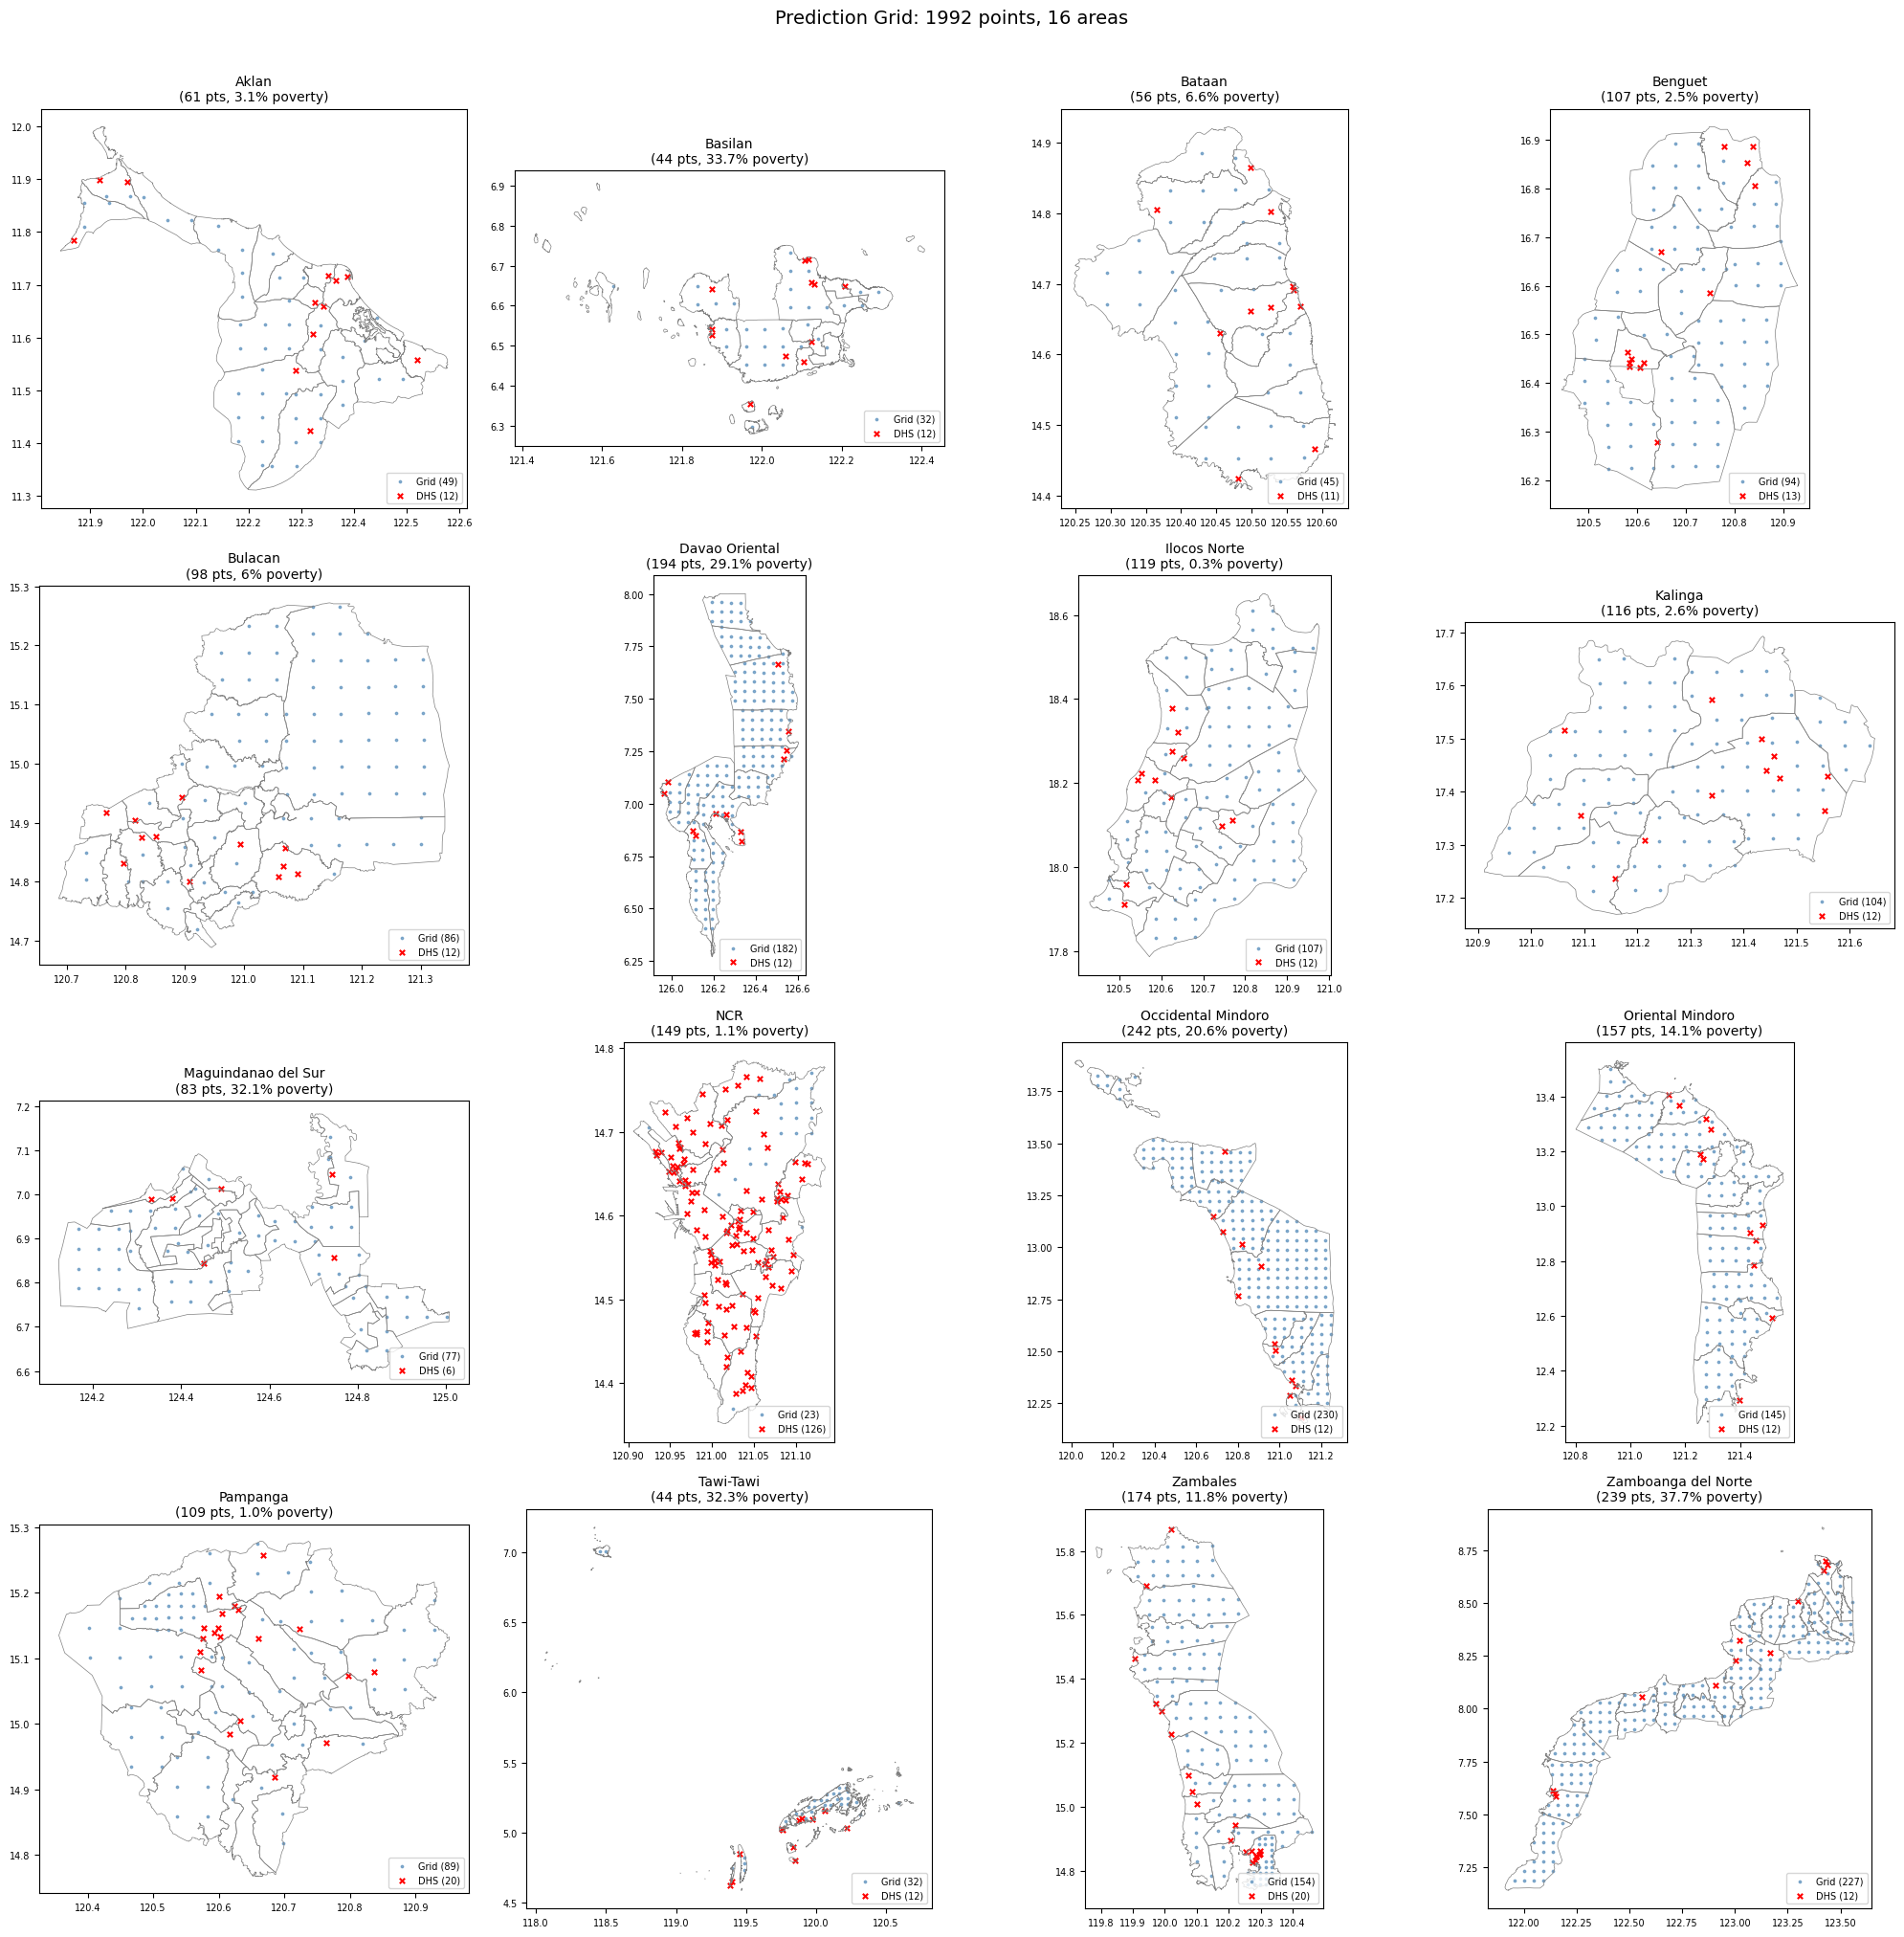

In [15]:
# ============================================================
# 6. QUICK MAP
# ============================================================

import matplotlib.pyplot as plt

provinces = sorted(gdf_out['Province'].unique())
n_prov = len(provinces)
ncols = 4
nrows = (n_prov + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for i, prov in enumerate(provinces):
    ax = axes[i]
    prov_bounds = gdf_target[gdf_target[COL_PROVINCE] == prov].to_crs('EPSG:4326')
    prov_bounds.boundary.plot(ax=ax, color='gray', linewidth=0.5)

    pts = gdf_out[gdf_out['Province'] == prov]
    grid_pts = pts[pts['source'] == 'grid']
    dhs_pts = pts[pts['source'] == 'DHS']

    if len(grid_pts) > 0:
        ax.scatter(grid_pts['Longitude'], grid_pts['Latitude'],
                   s=3, c='steelblue', alpha=0.6, label=f'Grid ({len(grid_pts)})')
    if len(dhs_pts) > 0:
        ax.scatter(dhs_pts['Longitude'], dhs_pts['Latitude'],
                   s=15, c='red', marker='x', label=f'DHS ({len(dhs_pts)})')

    poverty = POVERTY_RATES.get(prov, '')
    ax.set_title(f"{prov}\n({len(pts)} pts, {poverty}% poverty)", fontsize=10)
    ax.legend(fontsize=7, loc='lower right')
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Prediction Grid: {len(gdf_out)} points, {n_prov} areas', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/prediction_grid_overview.png', dpi=150, bbox_inches='tight')
plt.show()